In [2]:
# !pip install pandas sbi
# !pip install seaborn
# !pip install pyabc

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from episbi.models import Transition, compartment_model
from episbi.prior import UniformPrior
from episbi.inference import SBIEngine
from episbi import simulate_for_sbi
from episbi.utils import plot_prediction_windows


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
model_type = "deterministic"
simulator_extra_kwargs = {"observation_error": "poisson"}
simulation_cpu_cores = 4
num_prior_simulations = 10_000

initial_conditions = {"S": 99_990, "E": 0, "I": 10, "R": 0}
theta_true = {"beta": 0.80, "kappa": 0.30, "gamma": 0.35}
total_days = 100
inference_days = 80
forecast_days = total_days - inference_days
output_name = "E_to_I"


In [6]:
compartments = ["S", "E", "I", "R"]
transitions = [
    Transition("S", "E", "beta * S * I / N", name="S_to_E"),
    Transition("E", "I", "kappa * E", name="E_to_I"),
    Transition("I", "R", "gamma * I", name="I_to_R"),
]

seir_model = compartment_model(
    compartments=compartments,
    transitions=transitions,
    param_names=["beta", "kappa", "gamma"],
    model_type=model_type,
    initial_conditions=initial_conditions,
    observed={"transitions": [output_name]},
)

print(seir_model.show())


Model type: deterministic
Compartments: S, E, I, R
Parameters: beta, kappa, gamma
Transitions:
  S_to_E: S -> E, rate=beta * S * I / N
  E_to_I: E -> I, rate=kappa * E
  I_to_R: I -> R, rate=gamma * I
Observed:
  E_to_I


In [8]:
prior = UniformPrior(
    {
        "beta": (0.20, 1.20),
        "kappa": (0.10, 0.60),
        "gamma": (0.05, 0.60),
    },
    device=device,
)

In [9]:
thetas, xs = simulate_for_sbi(
    prior=prior,
    simulator=seir_model,
    num_simulations=num_prior_simulations,
    total_days=total_days,
    seed=0,
    simulator_kwargs=simulator_extra_kwargs,
    n_jobs=simulation_cpu_cores,
)

thetas_train = thetas
xs_train = xs[:, :inference_days, :]

thetas.shape, xs.shape, xs_train.shape

((10000, 3), (10000, 100, 1), (10000, 80, 1))

In [10]:
observed_result = seir_model(
    theta_true,
    total_days=total_days,
    seed=0,
    **simulator_extra_kwargs,
)
observed = observed_result[output_name]
obs_train = observed[:inference_days]

observed.shape, obs_train.shape

((100,), (80,))

In [11]:
engine = SBIEngine(batch_size=256, device=device)
npe_result = engine.run_npe(
    obs_data=obs_train,
    prior=prior,
    thetas=thetas_train,
    xs=xs_train,
    input_dim=1,
    num_samples=1_000,
    show_train_summary=False,
)

posterior = npe_result["posterior"]
posterior_samples = npe_result["samples"].detach().cpu().numpy()
posterior_samples.shape

[*] Running NPE (use_lstm=False) with batch size 256...


/usr/local/lib/python3.11/dist-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'cuda:0'. Moving x to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/usr/local/lib/python3.11/dist-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'cuda:0'. Moving theta to the data_device 'cuda'. Training will proceed on device 'cuda'.
  theta, x = validate_theta_and_x(
/usr/local/lib/python3.11/dist-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 120 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 3)

In [12]:
param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()


,beta,kappa,gamma
count,1000.000000,1000.000000,1000.000000
mean,0.801046,0.314480,0.343124
std,0.166992,0.072985,0.070812
min,0.432772,0.209714,0.168021
25%,0.675843,0.261615,0.289495
50%,0.789193,0.296788,0.338763
75%,0.914050,0.348580,0.392225
max,1.189773,0.588070,0.509168


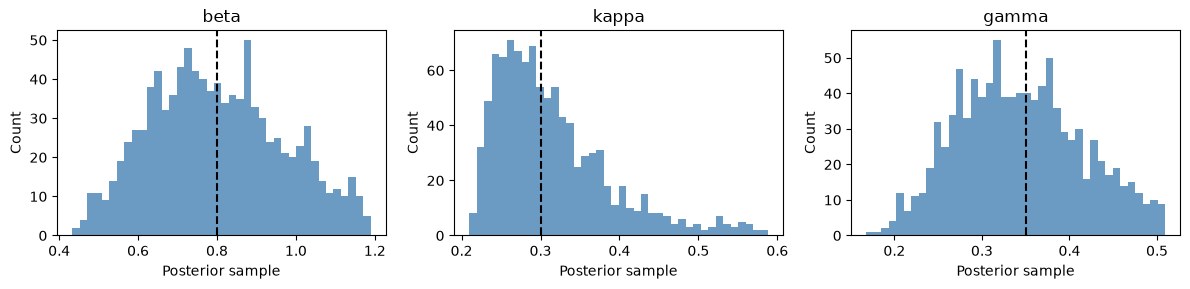

In [13]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(theta_true[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()


In [14]:
posterior_predictive = []

for _, theta in param_df.iloc[:300].iterrows():
    theta_dict = prior.to_dict(theta)
    sim = seir_model(
        theta_dict,
        total_days=total_days,
        **simulator_extra_kwargs,
    )[output_name]
    posterior_predictive.append(sim)

posterior_predictive = np.stack(posterior_predictive)[:, :, None]
posterior_predictive.shape


(300, 100, 1)

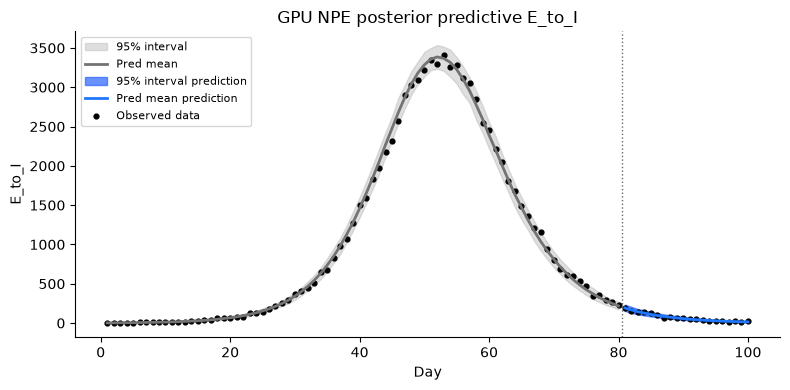

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_prediction_windows(
    y_obs=observed[:, None],
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_index=0,
    title=f"GPU NPE posterior predictive {output_name}",
    ylabel=output_name,
    ax=ax,
)
fig.tight_layout()
plt.show()
